# Police Call Modeling Notebook

This notebook builds an interpretable workload-surge model on 15-minute police call windows.

## Modeling objective

Predict whether the next 15-minute window is a workload surge (top quartile of call volume) using only past and calendar information.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    precision_recall_curve
)

plt.rcParams["figure.figsize"] = (11, 5)

In [6]:
data_path = Path("policacalls_adjusted/policecalls_adjusted_all.csv")
if not data_path.exists():
    raise FileNotFoundError(f"Missing cleaned dataset: {data_path.resolve()}")

df = pd.read_csv(data_path, low_memory=False)
print("Raw shape:", df.shape)
display(df.head())

Raw shape: (1170764, 15)


,CDTS,EID,START_DATE,CALL_NUMBER,PRIORITY,REPORT_DATE,OFFENSE_DATE,OFFENSE_TIME,CALLTYPE_CODE,CALL_TYPE,FINAL_DISPO_CODE,FINAL_DISPO,ADDRESS,CITY,STATE
0,2022-01-01 00:03:07,8912988,2022-01-01,P220010006,4,2022-01-01,2022-01-01,00:00:59,415FC,"DISTURBANCE, FIRECRACKERS",CAN,Canceled,BRANHAM LN & SNELL AV,San Jose,CA
1,2022-01-01 00:03:54,8912992,2022-01-01,P220010008,2,2022-01-01,2022-01-01,00:03:05,1057,FIREARMS DISCHARGED,CAN,Canceled,STOCKTON AV & SCHIELE AV,San Jose,CA
2,2022-01-01 00:06:18,8912993,2022-01-01,P220010009,4,2022-01-01,2022-01-01,00:03:41,415FC,"DISTURBANCE, FIRECRACKERS",CAN,Canceled,NEW JERSEY AV & DRY CREEK RD,San Jose,CA
3,2022-01-01 00:08:03,8912996,2022-01-01,P220010012,4,2022-01-01,2022-01-01,00:07:55,415FC,"DISTURBANCE, FIRECRACKERS",CAN,Canceled,JARVIS AV & BOURET DR,San Jose,CA
4,2022-01-01 00:11:15,8912991,2022-01-01,P220010007,6,2022-01-01,2022-01-01,00:03:03,1095,PEDESTRIAN STOP,N,No report required; dispatch record only,MERIDIAN AV & CURTNER AV,San Jose,CA


In [7]:
def parse_cdts_series(raw_series: pd.Series) -> pd.Series:
    s = (
        raw_series.astype("string")
                  .str.upper()
                  .str.replace("PS", "", regex=False)
                  .str.strip()
    )

    digits14 = s.str.extract(r"(\\d{14})", expand=False)
    parsed = pd.to_datetime(digits14, format="%Y%m%d%H%M%S", errors="coerce")

    missing_mask = parsed.isna()
    if missing_mask.any():
        digits12 = s[missing_mask].str.extract(r"(\\d{12})", expand=False)
        parsed12 = pd.to_datetime(digits12 + "00", format="%Y%m%d%H%M%S", errors="coerce")
        parsed.loc[missing_mask] = parsed12.values

    missing_mask = parsed.isna()
    if missing_mask.any():
        parsed_fallback = pd.to_datetime(s[missing_mask], errors="coerce")
        parsed.loc[missing_mask] = parsed_fallback.values

    return parsed

df["CDTS"] = parse_cdts_series(df["CDTS"])
df = df.dropna(subset=["CDTS"]).copy()
df = df.sort_values("CDTS").reset_index(drop=True)

if "FINAL_DISPO" in df.columns:
    df["FINAL_DISPO"] = df["FINAL_DISPO"].astype(str).str.strip()
    df["is_canceled"] = df["FINAL_DISPO"].str.upper().str.contains("CANCEL", na=False).astype("int8")
else:
    df["is_canceled"] = 0

if "PRIORITY" in df.columns:
    df["PRIORITY"] = pd.to_numeric(df["PRIORITY"], errors="coerce")
else:
    df["PRIORITY"] = np.nan

df["is_priority_1"] = (df["PRIORITY"] == 1).astype("int8")

if "CALL_TYPE" not in df.columns:
    df["CALL_TYPE"] = "Unknown"

print("Rows after timestamp parsing:", len(df))
print("Date range:", df["CDTS"].min(), "to", df["CDTS"].max())

Rows after timestamp parsing: 1170764
Date range: 2022-01-01 00:03:07 to 2026-03-19 05:31:36


In [8]:
time_bin_size = "15min"
df["time_bin"] = df["CDTS"].dt.floor(time_bin_size)

agg = (
    df.groupby("time_bin", as_index=False)
      .agg(
          total_calls=("CDTS", "size"),
          canceled_calls=("is_canceled", "sum"),
          priority_1_calls=("is_priority_1", "sum"),
          unique_call_types=("CALL_TYPE", "nunique")
      )
)

agg["cancel_rate"] = np.where(
    agg["total_calls"] > 0,
    agg["canceled_calls"] / agg["total_calls"],
    0.0
)
agg["priority_1_share"] = np.where(
    agg["total_calls"] > 0,
    agg["priority_1_calls"] / agg["total_calls"],
    0.0
)

agg["year"] = agg["time_bin"].dt.year
agg["month"] = agg["time_bin"].dt.month
agg["hour"] = agg["time_bin"].dt.hour
agg["day_of_week"] = agg["time_bin"].dt.day_name()
agg["is_weekend"] = (agg["time_bin"].dt.dayofweek >= 5).astype("int8")

agg = agg.sort_values("time_bin").reset_index(drop=True)
display(agg.head())
print("Aggregated windows:", len(agg))

,time_bin,total_calls,canceled_calls,priority_1_calls,unique_call_types,cancel_rate,priority_1_share,year,month,hour,day_of_week,is_weekend
0,2022-01-01 00:00:00,6,5,0,3,0.833333,0.000000,2022,1,0,Saturday,1
1,2022-01-01 00:15:00,7,6,0,1,0.857143,0.000000,2022,1,0,Saturday,1
2,2022-01-01 00:30:00,10,4,0,6,0.400000,0.000000,2022,1,0,Saturday,1
3,2022-01-01 00:45:00,6,1,1,6,0.166667,0.166667,2022,1,0,Saturday,1
4,2022-01-01 01:00:00,13,7,2,10,0.538462,0.153846,2022,1,1,Saturday,1


Aggregated windows: 145620


In [9]:
surge_threshold = agg["total_calls"].quantile(0.75)
agg["is_surge"] = (agg["total_calls"] >= surge_threshold).astype("int8")

for lag in [1, 2, 4, 8, 12, 24]:
    agg[f"lag_calls_{lag}"] = agg["total_calls"].shift(lag)

for lag in [1, 4, 8]:
    agg[f"lag_cancel_rate_{lag}"] = agg["cancel_rate"].shift(lag)

for lag in [1, 4, 8]:
    agg[f"lag_priority1_share_{lag}"] = agg["priority_1_share"].shift(lag)

agg["rolling_calls_mean_4"] = agg["total_calls"].shift(1).rolling(4).mean()
agg["rolling_calls_mean_12"] = agg["total_calls"].shift(1).rolling(12).mean()
agg["rolling_calls_std_12"] = agg["total_calls"].shift(1).rolling(12).std()

agg["rolling_cancel_mean_12"] = agg["cancel_rate"].shift(1).rolling(12).mean()
agg["rolling_priority1_mean_12"] = agg["priority_1_share"].shift(1).rolling(12).mean()

agg_model = agg.dropna().copy()

print(f"Surge threshold (Q3): {surge_threshold:.2f} calls per 15-min window")
print("Modeling rows after lag/rolling features:", len(agg_model))
print("Surge class balance:")
display(agg_model["is_surge"].value_counts(normalize=True).rename("proportion"))

Surge threshold (Q3): 11.00 calls per 15-min window
Modeling rows after lag/rolling features: 145596
Surge class balance:


is_surge
0    0.740611
1    0.259389
Name: proportion, dtype: float64

In [10]:
available_years = sorted(agg_model["year"].unique())
print("Available years in modeling table:", available_years)

if 2025 in available_years and 2026 in available_years:
    train_mask = agg_model["year"] <= 2024
    val_mask = agg_model["year"] == 2025
    test_mask = agg_model["year"] >= 2026
elif 2025 in available_years:
    train_mask = agg_model["year"] <= 2024
    val_mask = agg_model["year"] == 2025
    test_mask = agg_model["year"] == 2025
else:
    cutoff = np.quantile(agg_model["time_bin"].view("int64"), 0.8)
    train_mask = agg_model["time_bin"].view("int64") < cutoff
    val_mask = agg_model["time_bin"].view("int64") >= cutoff
    test_mask = val_mask

feature_cols = [
    "month", "hour", "day_of_week", "is_weekend",
    "lag_calls_1", "lag_calls_2", "lag_calls_4", "lag_calls_8", "lag_calls_12", "lag_calls_24",
    "lag_cancel_rate_1", "lag_cancel_rate_4", "lag_cancel_rate_8",
    "lag_priority1_share_1", "lag_priority1_share_4", "lag_priority1_share_8",
    "rolling_calls_mean_4", "rolling_calls_mean_12", "rolling_calls_std_12",
    "rolling_cancel_mean_12", "rolling_priority1_mean_12",
    "unique_call_types"
]
target_col = "is_surge"

X_train = agg_model.loc[train_mask, feature_cols].copy()
y_train = agg_model.loc[train_mask, target_col].copy()
X_val = agg_model.loc[val_mask, feature_cols].copy()
y_val = agg_model.loc[val_mask, target_col].copy()
X_test = agg_model.loc[test_mask, feature_cols].copy()
y_test = agg_model.loc[test_mask, target_col].copy()

if X_val.empty:
    raise ValueError("Validation split is empty. Check year coverage in the dataset.")
if X_test.empty:
    raise ValueError("Test split is empty. Check year coverage in the dataset.")

print("Train rows:", len(X_train), " | surge rate:", round(y_train.mean(), 3))
print("Val rows:", len(X_val), " | surge rate:", round(y_val.mean(), 3))
print("Test rows:", len(X_test), " | surge rate:", round(y_test.mean(), 3))

Available years in modeling table: [np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]
Train rows: 103663  | surge rate: 0.28
Val rows: 34625  | surge rate: 0.214
Test rows: 7308  | surge rate: 0.186


In [11]:
categorical_cols = ["day_of_week"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop"
)

baseline_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]
)

main_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=400,
            max_depth=10,
            min_samples_leaf=8,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]
)

In [12]:
def best_f1_threshold(y_true: pd.Series, y_prob: np.ndarray) -> float:
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1_vals = (2 * precision * recall) / (precision + recall + 1e-12)
    if len(thresholds) == 0:
        return 0.5
    best_idx = int(np.nanargmax(f1_vals[:-1]))
    return float(thresholds[best_idx])

def collect_metrics(y_true: pd.Series, y_prob: np.ndarray, threshold: float) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob)
    }

In [13]:
baseline_model.fit(X_train, y_train)
main_model.fit(X_train, y_train)

baseline_val_prob = baseline_model.predict_proba(X_val)[:, 1]
main_val_prob = main_model.predict_proba(X_val)[:, 1]

baseline_threshold = best_f1_threshold(y_val, baseline_val_prob)
main_threshold = best_f1_threshold(y_val, main_val_prob)

baseline_test_prob = baseline_model.predict_proba(X_test)[:, 1]
main_test_prob = main_model.predict_proba(X_test)[:, 1]

summary = pd.DataFrame([
    {"model": "Logistic baseline", "split": "validation", **collect_metrics(y_val, baseline_val_prob, baseline_threshold)},
    {"model": "Random forest main", "split": "validation", **collect_metrics(y_val, main_val_prob, main_threshold)},
    {"model": "Logistic baseline", "split": "test", **collect_metrics(y_test, baseline_test_prob, baseline_threshold)},
    {"model": "Random forest main", "split": "test", **collect_metrics(y_test, main_test_prob, main_threshold)}
])

print(f"Baseline threshold (val F1-opt): {baseline_threshold:.3f}")
print(f"Main threshold (val F1-opt): {main_threshold:.3f}")
display(summary.round(3))

Baseline threshold (val F1-opt): 0.687
Main threshold (val F1-opt): 0.683


,model,split,precision,recall,f1,roc_auc,pr_auc
0,Logistic baseline,validation,0.793,0.798,0.796,0.962,0.895
1,Random forest main,validation,0.780,0.810,0.794,0.960,0.877
2,Logistic baseline,test,0.782,0.776,0.779,0.963,0.877
3,Random forest main,test,0.767,0.780,0.774,0.959,0.852


Random forest classification report on test split:
              precision    recall  f1-score   support

           0      0.950     0.946     0.948      5951
           1      0.767     0.780     0.774      1357

    accuracy                          0.915      7308
   macro avg      0.859     0.863     0.861      7308
weighted avg      0.916     0.915     0.916      7308



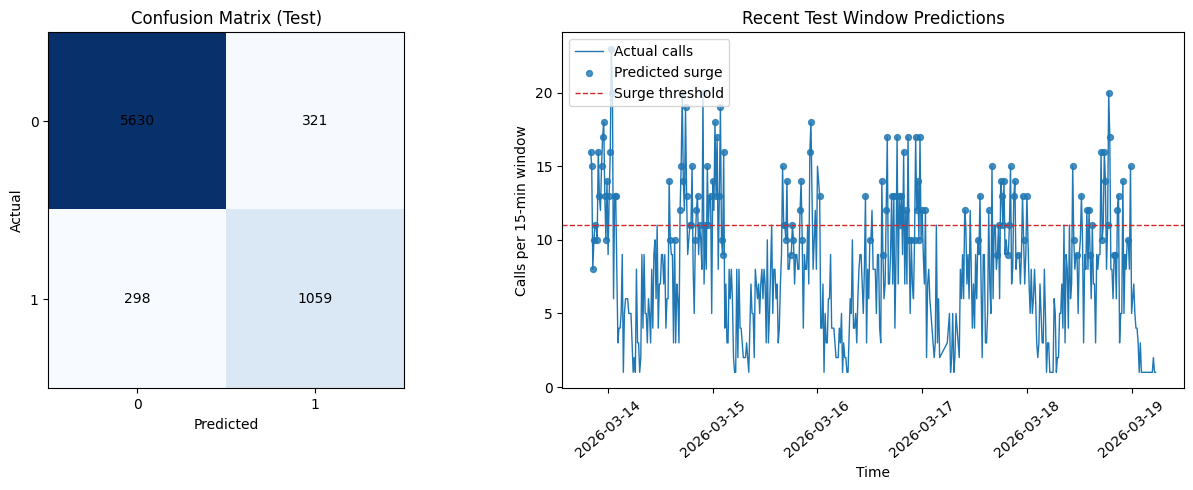

In [16]:
main_test_pred = (main_test_prob >= main_threshold).astype(int)
cm = confusion_matrix(y_test, main_test_pred)
print("Random forest classification report on test split:")
print(classification_report(y_test, main_test_pred, digits=3, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion Matrix (Test)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, int(cm[i, j]), ha="center", va="center", color="black")

test_frame = agg_model.loc[test_mask, ["time_bin", "total_calls", "is_surge"]].copy()
test_frame["surge_prob"] = main_test_prob
test_frame["pred_surge"] = main_test_pred
plot_points = test_frame.tail(500).copy()

axes[1].plot(plot_points["time_bin"], plot_points["total_calls"], label="Actual calls", linewidth=1.0)
axes[1].scatter(
    plot_points.loc[plot_points["pred_surge"] == 1, "time_bin"],
    plot_points.loc[plot_points["pred_surge"] == 1, "total_calls"],
    s=18,
    label="Predicted surge",
    alpha=0.8
)
axes[1].axhline(surge_threshold, color="tab:red", linestyle="--", linewidth=1.0, label="Surge threshold")
axes[1].set_title("Recent Test Window Predictions")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Calls per 15-min window")
axes[1].tick_params(axis="x", rotation=40)
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

,feature,importance
0,unique_call_types,0.635680
1,rolling_calls_mean_4,0.087899
2,rolling_calls_mean_12,0.072003
3,hour,0.065285
4,lag_calls_1,0.029934
5,lag_calls_2,0.026020
6,lag_calls_4,0.018262
7,rolling_calls_std_12,0.012751
8,lag_calls_8,0.012504
9,lag_calls_12,0.005916


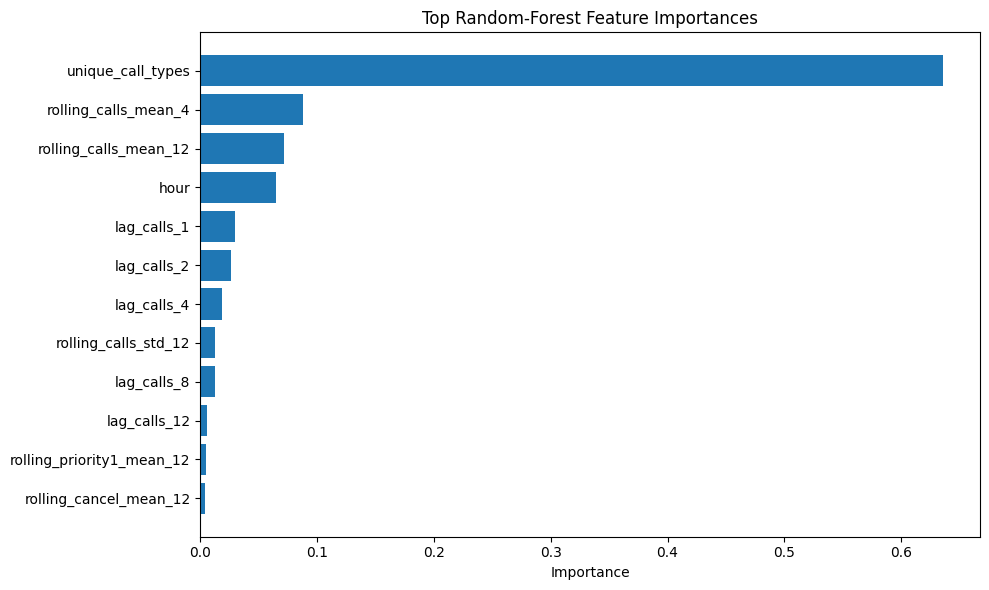

In [15]:
rf = main_model.named_steps["model"]
ohe = main_model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(["day_of_week"]))
all_feature_names = numeric_cols + cat_feature_names

importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(importance.head(15))

plt.figure(figsize=(10, 6))
top_imp = importance.head(12).iloc[::-1]
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("Top Random-Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Next improvements

1. Add walk-forward validation across multiple folds instead of one fixed split.
2. Compare fixed operational thresholds to quantile-based surge definitions.
3. Add calibration analysis if probabilities will be used directly for staffing alerts.